# Eda_exploration_brute

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 12
 
print("✅ Librairies importées avec succès")

✅ Librairies importées avec succès


# Charger worldbank_merged.csv

In [47]:
df_wb = pd.read_csv('../data/raw/worldbank_merged.csv')
 
print("=" * 55)
print("FICHIER : worldbank_merged.csv")
print("=" * 55)
print(f"  Lignes   : {df_wb.shape[0]}")
print(f"  Colonnes : {df_wb.shape[1]}")
print(f"  Colonnes disponibles : {df_wb.columns.tolist()}")

FICHIER : worldbank_merged.csv
  Lignes   : 1222
  Colonnes : 12
  Colonnes disponibles : ['country_code', 'year', 'gdp_growth', 'inflation', 'population', 'gni_per_capita', 'life_expectancy', 'literacy_rate', 'country_name', 'region', 'income_level', 'gdp_per_capita']


# Charger happiness_all_years.csv

In [48]:
df_hap = pd.read_csv('../data/raw/happiness_all_years.csv')
 
print("\n" + "=" * 55)
print("FICHIER : happiness_all_years.csv")
print("=" * 55)
print(f"  Lignes   : {df_hap.shape[0]}")
print(f"  Colonnes : {df_hap.shape[1]}")
print(f"  Colonnes disponibles : {df_hap.columns.tolist()}")


FICHIER : happiness_all_years.csv
  Lignes   : 962
  Colonnes : 11
  Colonnes disponibles : ['country_name', 'year', 'happiness_score', 'social_support', 'freedom', 'generosity', 'corruption', 'log_gdp_per_capita', 'life_expectancy_whr', 'positive_affect', 'negative_affect']


# Vérifier les dimensions (shape) des deux fichiers

In [49]:
print("\n" + "=" * 55)
print("DIMENSIONS DES DEUX FICHIERS")
print("=" * 55)
print(f"  World Bank     → {df_wb.shape[0]:>5} lignes × {df_wb.shape[1]:>2} colonnes")
print(f"  Happiness WHR  → {df_hap.shape[0]:>5} lignes × {df_hap.shape[1]:>2} colonnes")
print(f"  Total lignes   → {df_wb.shape[0] + df_hap.shape[0]} lignes au total")
 


DIMENSIONS DES DEUX FICHIERS
  World Bank     →  1222 lignes × 12 colonnes
  Happiness WHR  →   962 lignes × 11 colonnes
  Total lignes   → 2184 lignes au total


# Afficher les premières lignes (head)

In [50]:
print("\n" + "=" * 55)
print("PREMIÈRES LIGNES — World Bank")
print("=" * 55)
print(df_wb.head(5).to_string())
 
print("\n" + "=" * 55)
print("PREMIÈRES LIGNES — Happiness Report")
print("=" * 55)
print(df_hap.head(5).to_string())


PREMIÈRES LIGNES — World Bank
  country_code  year  gdp_growth  inflation  population  gni_per_capita  life_expectancy  literacy_rate country_name                      region income_level  gdp_per_capita
0          ABW  2015    3.611480        NaN    107906.0         25430.0              NaN            NaN        Aruba  Latin America & Caribbean   High income    27458.220154
1          ABW  2016    1.234335        NaN    108727.0         25560.0              NaN            NaN        Aruba  Latin America & Caribbean   High income    27441.550214
2          ABW  2017    3.493430        NaN    108735.0         26460.0              NaN            NaN        Aruba  Latin America & Caribbean   High income    28440.041688
3          ABW  2018    3.212471        NaN    108908.0         27970.0              NaN            NaN        Aruba  Latin America & Caribbean   High income    30082.158423
4          ABW  2019    1.225112        NaN    109203.0         29320.0              NaN           

# Calculer le nombre de nulls par colonne

In [51]:
print("\n" + "=" * 55)
print("TÂCHE 2.2 — VALEURS MANQUANTES")
print("=" * 55)
 
nulls_wb  = df_wb.isnull().sum()
nulls_hap = df_hap.isnull().sum()
 
print("\nNombre de valeurs NULL — World Bank :")
print(nulls_wb.to_string())
 
print("\nNombre de valeurs NULL — Happiness :")
print(nulls_hap.to_string())


TÂCHE 2.2 — VALEURS MANQUANTES

Nombre de valeurs NULL — World Bank :
country_code          0
year                  0
gdp_growth          253
inflation          1212
population          212
gni_per_capita      754
life_expectancy    1213
literacy_rate       850
country_name          0
region                0
income_level          0
gdp_per_capita       45

Nombre de valeurs NULL — Happiness :
country_name             0
year                     0
happiness_score          0
social_support           2
freedom                  9
generosity              30
corruption              53
log_gdp_per_capita     175
life_expectancy_whr    174
positive_affect        155
negative_affect        155


# Calculer le pourcentage de complétude par colonne

In [52]:
print("\n" + "=" * 55)
print("POURCENTAGE DE COMPLÉTUDE PAR COLONNE")
print("=" * 55)
 
completude_wb = pd.DataFrame({
    'Nulls'        : nulls_wb,
    'Completude_%' : (100 - nulls_wb / len(df_wb) * 100).round(1)
}).sort_values('Completude_%')
 
completude_hap = pd.DataFrame({
    'Nulls'        : nulls_hap,
    'Completude_%' : (100 - nulls_hap / len(df_hap) * 100).round(1)
}).sort_values('Completude_%')
 
print("\nWorld Bank — Complétude :")
print(completude_wb.to_string())
 
print("\nHappiness — Complétude :")
print(completude_hap.to_string())


POURCENTAGE DE COMPLÉTUDE PAR COLONNE

World Bank — Complétude :
                 Nulls  Completude_%
life_expectancy   1213           0.7
inflation         1212           0.8
literacy_rate      850          30.4
gni_per_capita     754          38.3
gdp_growth         253          79.3
population         212          82.7
gdp_per_capita      45          96.3
country_code         0         100.0
year                 0         100.0
country_name         0         100.0
region               0         100.0
income_level         0         100.0

Happiness — Complétude :
                     Nulls  Completude_%
log_gdp_per_capita     175          81.8
life_expectancy_whr    174          81.9
positive_affect        155          83.9
negative_affect        155          83.9
corruption              53          94.5
generosity              30          96.9
freedom                  9          99.1
social_support           2          99.8
country_name             0         100.0
year             

# Générer la heatmap des valeurs manquantes

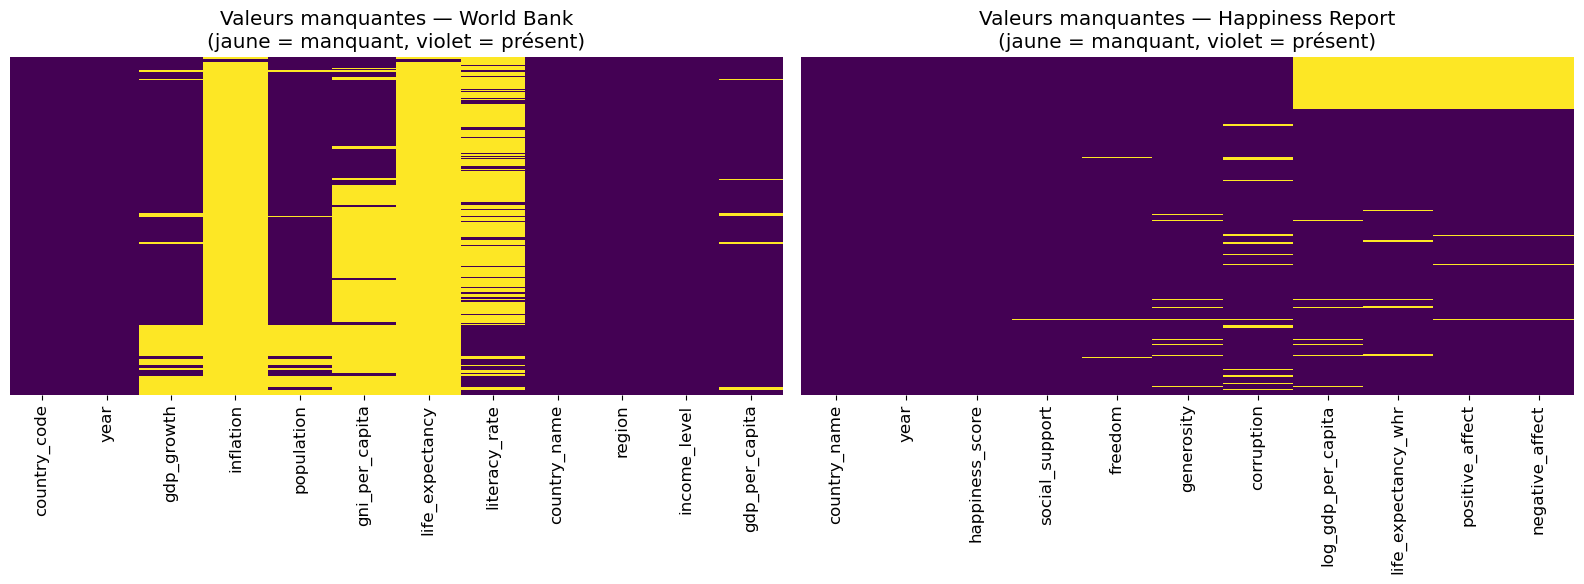

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
sns.heatmap(df_wb.isnull(),
            cbar=False, cmap='viridis',
            yticklabels=False, ax=axes[0])
axes[0].set_title('Valeurs manquantes — World Bank\n(jaune = manquant, violet = présent)')
 
sns.heatmap(df_hap.isnull(),
            cbar=False, cmap='viridis',
            yticklabels=False, ax=axes[1])
axes[1].set_title('Valeurs manquantes — Happiness Report\n(jaune = manquant, violet = présent)')
 
plt.tight_layout()

# DÉTECTION DES DOUBLONS

### Définition des colonnes clés

In [54]:
col_code = 'country_code' if 'country_code' in df_wb.columns else df_wb.columns[0]
col_year = 'year'         if 'year'         in df_wb.columns else df_wb.columns[1]
col_country_hap = 'country' if 'country' in df_hap.columns else df_hap.columns[0]
col_year_hap    = 'year'    if 'year'    in df_hap.columns else 'Year'
 

### Compter les doublons dans World Bank

In [55]:
print("\n" + "=" * 55)
print("TÂCHE 2.3 — DÉTECTION DES DOUBLONS")
print("=" * 55)
 
doublons_wb = df_wb.duplicated().sum()
print(f"\nDoublons complets World Bank  : {doublons_wb}")
 
if doublons_wb > 0:
    print(" Exemples :")
    print(df_wb[df_wb.duplicated(keep=False)].head(6).to_string())
else:
    print(" Aucun doublon complet dans World Bank")


TÂCHE 2.3 — DÉTECTION DES DOUBLONS

Doublons complets World Bank  : 0
 Aucun doublon complet dans World Bank


### Compter les doublons dans Happiness Report

In [56]:
doublons_hap = df_hap.duplicated().sum()
print(f"\nDoublons complets Happiness   : {doublons_hap}")
 
if doublons_hap > 0:
    print(" Exemples :")
    print(df_hap[df_hap.duplicated(keep=False)].head(6).to_string())
else:
    print(" Aucun doublon complet dans Happiness Report")


Doublons complets Happiness   : 0
 Aucun doublon complet dans Happiness Report


### Identifier les doublons sur (country_code, year)

In [57]:
doublons_cle = df_wb.duplicated(subset=[col_code, col_year]).sum()
print(f"\nDoublons sur clé ({col_code}, {col_year}) : {doublons_cle}")
 
if doublons_cle > 0:
    print(" Doublons sur la clé :")
    print(df_wb[df_wb.duplicated(subset=[col_code, col_year], keep=False)]
          .sort_values([col_code, col_year]).head(10).to_string())
else:
    print(f" Aucun doublon sur la clé ({col_code}, {col_year})")
 
print("\n--- Résumé Doublons ---")
print(f"  World Bank  doublons complets  : {doublons_wb}")
print(f"  World Bank  doublons sur clé   : {doublons_cle}")
print(f"  Happiness   doublons complets  : {doublons_hap}")


Doublons sur clé (country_code, year) : 0
 Aucun doublon sur la clé (country_code, year)

--- Résumé Doublons ---
  World Bank  doublons complets  : 0
  World Bank  doublons sur clé   : 0
  Happiness   doublons complets  : 0


#  VÉRIFICATION DES TYPES DE DONNÉES

### Vérifier les types World Bank

In [58]:
print("\n" + "=" * 55)
print("TÂCHE 2.4 — TYPES DE DONNÉES")
print("=" * 55)
 
print("\nWorld Bank — Types de chaque colonne :")
print("-" * 55)
for col in df_wb.columns:
    dtype   = df_wb[col].dtype
    exemple = df_wb[col].dropna().iloc[0] if df_wb[col].notna().any() else 'N/A'
    print(f"  {col:35s} → {str(dtype):10s}  ex: {exemple}")


TÂCHE 2.4 — TYPES DE DONNÉES

World Bank — Types de chaque colonne :
-------------------------------------------------------
  country_code                        → object      ex: ABW
  year                                → int64       ex: 2015
  gdp_growth                          → float64     ex: 3.61147995361162
  inflation                           → float64     ex: -0.661709164713742
  population                          → float64     ex: 107906.0
  gni_per_capita                      → float64     ex: 25430.0
  life_expectancy                     → float64     ex: 62.27
  literacy_rate                       → float64     ex: 35.9865546430738
  country_name                        → object      ex: Aruba
  region                              → object      ex: Latin America & Caribbean 
  income_level                        → object      ex: High income
  gdp_per_capita                      → float64     ex: 27458.2201537506


### Vérifier les types Happiness Report

In [59]:
print("\nHappiness Report — Types de chaque colonne :")
print("-" * 55)
for col in df_hap.columns:
    dtype   = df_hap[col].dtype
    exemple = df_hap[col].dropna().iloc[0] if df_hap[col].notna().any() else 'N/A'
    print(f"  {col:35s} → {str(dtype):10s}  ex: {exemple}")
 


Happiness Report — Types de chaque colonne :
-------------------------------------------------------
  country_name                        → object      ex: Finland
  year                                → int64       ex: 2021
  happiness_score                     → float64     ex: 7.842
  social_support                      → float64     ex: 0.954
  freedom                             → float64     ex: 0.949
  generosity                          → float64     ex: -0.098
  corruption                          → float64     ex: 0.186
  log_gdp_per_capita                  → float64     ex: 7.702
  life_expectancy_whr                 → float64     ex: 53.2
  positive_affect                     → float64     ex: 0.554
  negative_affect                     → float64     ex: 0.339


### Identifier les colonnes mal typées

In [60]:
print("\nColonnes potentiellement mal typées :")
print("-" * 55)
 
trouvees = False
for col in df_wb.columns:
    if df_wb[col].dtype == 'object':
        try:
            pd.to_numeric(df_wb[col].dropna(), errors='raise')
            print(f"   WB  — {col} : Texte mais contient des nombres → à convertir")
            trouvees = True
        except:
            pass
 
for col in df_hap.columns:
    if df_hap[col].dtype == 'object':
        try:
            pd.to_numeric(df_hap[col].dropna(), errors='raise')
            print(f"   HAP — {col} : Texte mais contient des nombres → à convertir")
            trouvees = True
        except:
            pass
 
if not trouvees:
    print("   Aucune colonne mal typée détectée")


Colonnes potentiellement mal typées :
-------------------------------------------------------
   Aucune colonne mal typée détectée


# Statistiques descriptives brutes

### Calculer moyenne, médiane, écart-type par colonne

In [61]:
print("\n" + "=" * 55)
print("TÂCHE 2.5 — STATISTIQUES DESCRIPTIVES BRUTES")
print("=" * 55)
 
cols_num_wb = df_wb.select_dtypes(include=[np.number]).columns.tolist()
if col_year in cols_num_wb:
    cols_num_wb.remove(col_year)
 
print("\nMoyenne | Médiane | Écart-type — World Bank :")
stats_wb = df_wb[cols_num_wb].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
print(stats_wb.to_string())
 
cols_num_hap = df_hap.select_dtypes(include=[np.number]).columns.tolist()
if col_year_hap in cols_num_hap:
    cols_num_hap.remove(col_year_hap)
 
print("\nMoyenne | Médiane | Écart-type — Happiness :")
stats_hap = df_hap[cols_num_hap].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
print(stats_hap.to_string())
 


TÂCHE 2.5 — STATISTIQUES DESCRIPTIVES BRUTES

Moyenne | Médiane | Écart-type — World Bank :
        gdp_growth  inflation    population  gni_per_capita  life_expectancy  literacy_rate  gdp_per_capita
mean          2.77       2.48  4.948962e+07        16155.81            62.91          85.08        17825.83
median        3.08       3.34  6.245228e+06         6795.00            62.44          93.22         7099.78
std           5.47       5.77  1.966177e+08        22642.49             1.82          17.13        22824.35
min         -23.90      -6.60  3.269900e+04          240.00            60.42          22.31          219.42
max          63.33      13.71  1.450936e+09       145150.00            66.04         100.00       142855.37

Moyenne | Médiane | Écart-type — Happiness :
        happiness_score  social_support  freedom  generosity  corruption  log_gdp_per_capita  life_expectancy_whr  positive_affect  negative_affect
mean               5.51            0.81     0.78       -0.01     

### Identifier les valeurs aberrantes (outliers)

In [62]:
print("\nDétection Outliers — méthode IQR :")
print("-" * 55)
 
for col in cols_num_wb:
    data = df_wb[col].dropna()
    if len(data) == 0:
        continue
    Q1  = data.quantile(0.25)
    Q3  = data.quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    up  = Q3 + 1.5 * IQR
    n   = ((data < low) | (data > up)).sum()
    pct = round(n / len(data) * 100, 1)
    st  = "⚠️" if n > 0 else "✅"
    print(f"  {st} {col:35s} : {n:4d} outliers ({pct}%)"
          f"  [min={data.min():.1f}, max={data.max():.1f}]")


Détection Outliers — méthode IQR :
-------------------------------------------------------
  ⚠️ gdp_growth                          :   76 outliers (7.8%)  [min=-23.9, max=63.3]
  ⚠️ inflation                           :    1 outliers (10.0%)  [min=-6.6, max=13.7]
  ⚠️ population                          :  137 outliers (13.6%)  [min=32699.0, max=1450935791.0]
  ⚠️ gni_per_capita                      :   52 outliers (11.1%)  [min=240.0, max=145150.0]
  ⚠️ life_expectancy                     :    3 outliers (33.3%)  [min=60.4, max=66.0]
  ⚠️ literacy_rate                       :   19 outliers (5.1%)  [min=22.3, max=100.0]
  ⚠️ gdp_per_capita                      :   89 outliers (7.6%)  [min=219.4, max=142855.4]


### Vérifier les valeurs min et max logiques


Vérification min/max logiques :
-------------------------------------------------------
  ✅ gdp_per_capita                 min=219.4  max=142855.4  anomalies=0
  ✅ gdp_growth                     min=-23.9  max=63.3  anomalies=0
  ✅ inflation                      min=-6.6  max=13.7  anomalies=0
  ✅ life_expectancy                min=60.4  max=66.0  anomalies=0
  ✅ literacy_rate                  min=22.3  max=100.0  anomalies=0


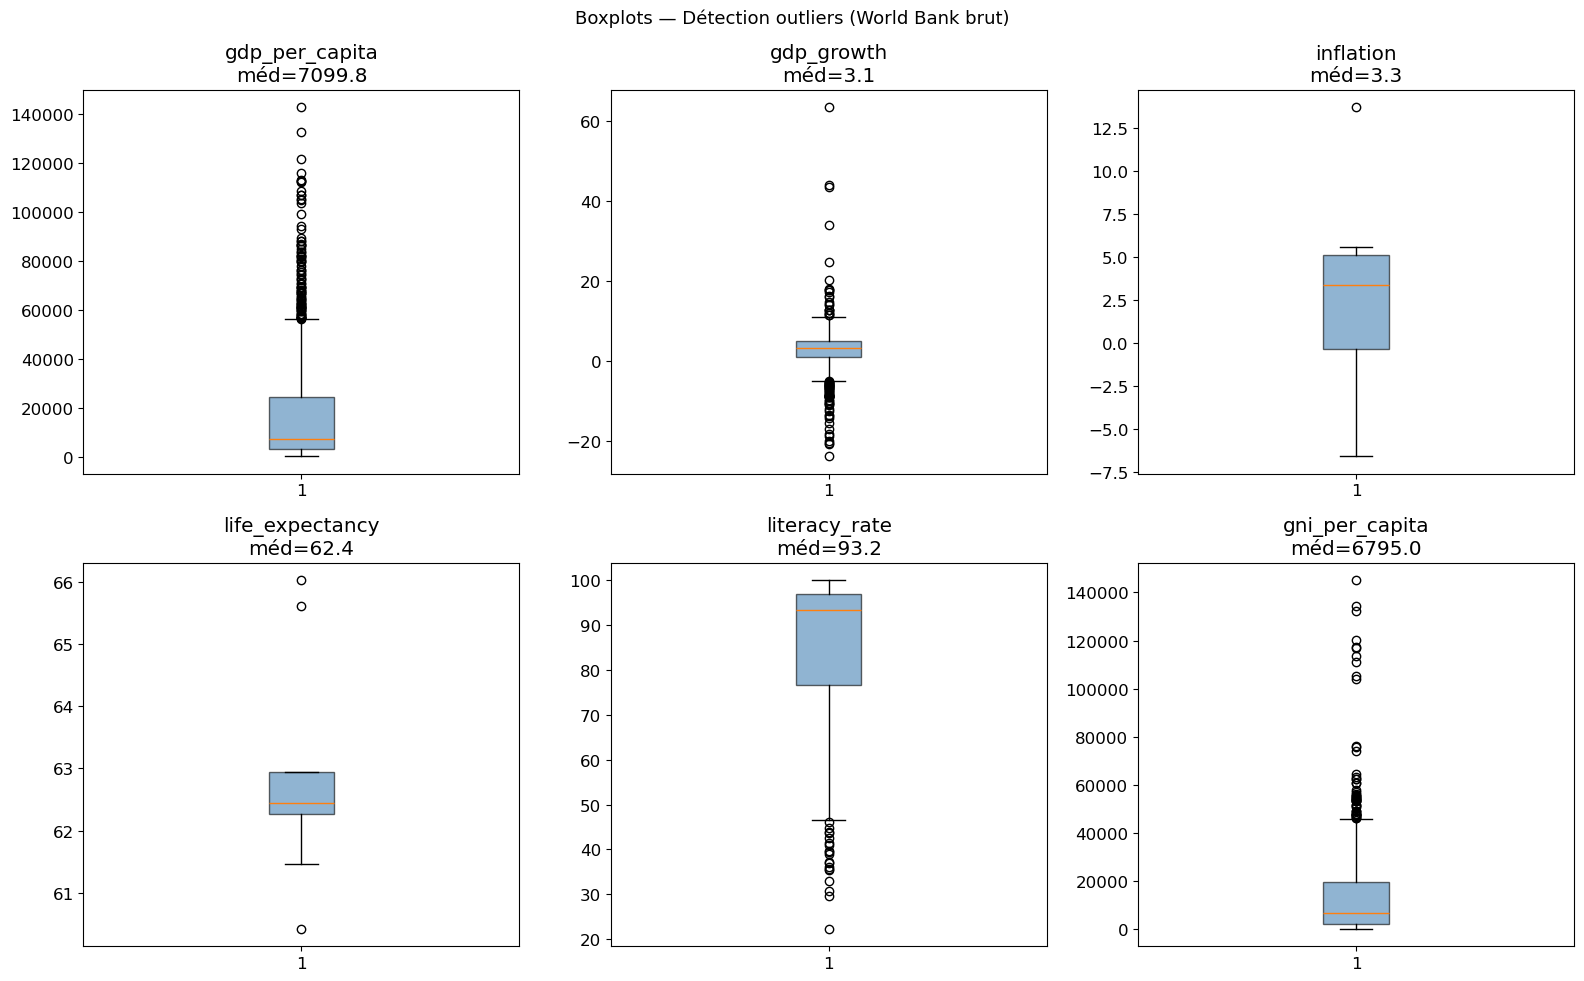

✅ Graphique sauvegardé : 00_boxplots_outliers.png


In [63]:
print("\nVérification min/max logiques :")
print("-" * 55)
 
verifs = [
    ('gdp_per_capita',  0,   200000, df_wb),
    ('gdp_growth',     -50,  100,    df_wb),
    ('inflation',      -10,  500,    df_wb),
    ('life_expectancy', 30,  90,     df_wb),
    ('literacy_rate',   0,   100,    df_wb),
]
for col, vmin, vmax, df in verifs:
    if col not in df.columns:
        continue
    data     = df[col].dropna()
    sous_min = (data < vmin).sum()
    sur_max  = (data > vmax).sum()
    st       = "✅" if sous_min == 0 and sur_max == 0 else "⚠️"
    print(f"  {st} {col:30s} min={data.min():.1f}  max={data.max():.1f}"
          f"  anomalies={sous_min + sur_max}")
 
# Boxplot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
cols_box = [c for c in ['gdp_per_capita', 'gdp_growth', 'inflation',
                         'life_expectancy', 'literacy_rate', 'gni_per_capita']
            if c in df_wb.columns][:6]
for i, col in enumerate(cols_box):
    data = df_wb[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}\nméd={data.median():.1f}')
plt.suptitle('Boxplots — Détection outliers (World Bank brut)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/plots/00_boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : 00_boxplots_outliers.png")
 

#  DISTRIBUTION DES INDICATEURS BRUTS

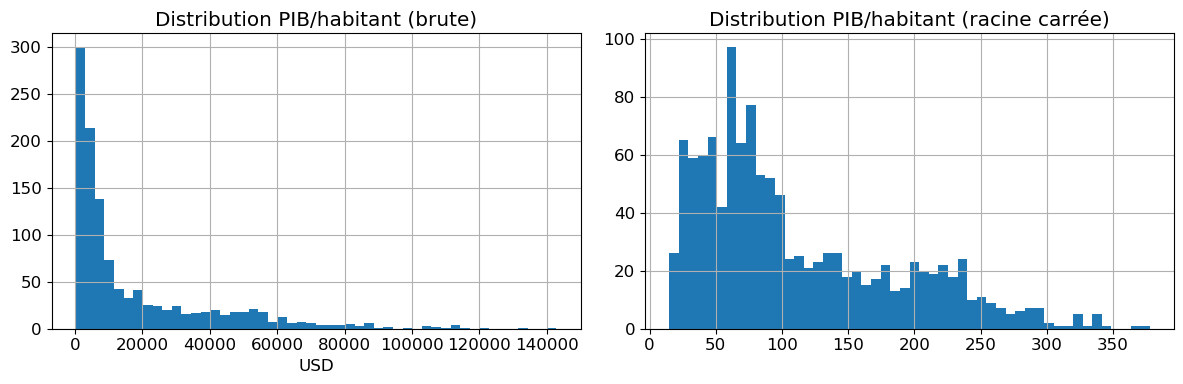

In [64]:

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df_raw['gdp_per_capita'].dropna().hist(bins=50)
plt.title('Distribution PIB/habitant (brute)')
plt.xlabel('USD')

plt.subplot(1, 2, 2)
df_raw['gdp_per_capita'].dropna().apply(lambda x: x**0.5 if x > 0 else 0).hist(bins=50)
plt.title('Distribution PIB/habitant (racine carrée)')
plt.tight_layout()
plt.savefig('../reports/plots/00_distribution_pib_brute.png', dpi=150)
plt.show()

# Nombre pays par année

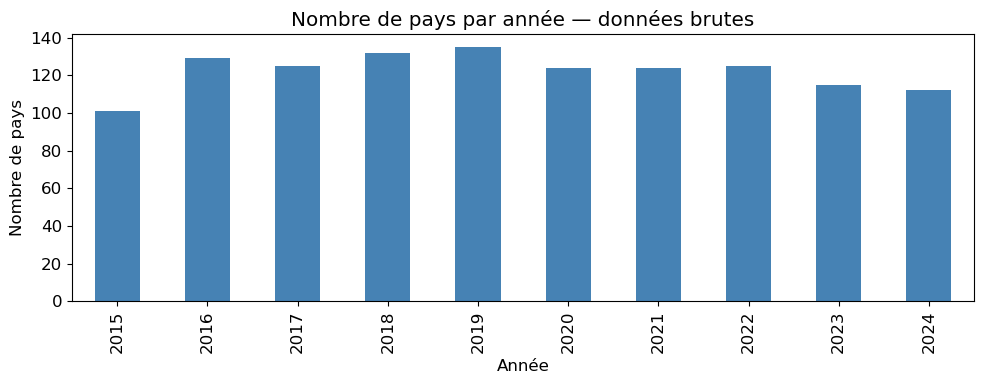

In [65]:

coverage = df_raw.groupby('year')['country_code'].count()
plt.figure(figsize=(10, 4))
coverage.plot(kind='bar', color='steelblue')
plt.title('Nombre de pays par année — données brutes')
plt.xlabel('Année')
plt.ylabel('Nombre de pays')
plt.tight_layout()
plt.savefig('../reports/plots/00_couverture_pays_annee.png', dpi=150)
plt.show()

In [66]:
print("\n" + "=" * 55)
print("TÂCHE 2.7 — COUVERTURE TEMPORELLE")
print("=" * 55)
 
coverage_wb = df_wb.groupby(col_year)[col_code].count()
 
print("\nWorld Bank — Pays par année :")
for annee, count in coverage_wb.items():
    st = "✅" if count >= 150 else "⚠️" if count >= 100 else "❌"
    print(f"  {st} {annee} : {count} pays")
 
coverage_hap = None
if col_year_hap in df_hap.columns:
    coverage_hap = df_hap.groupby(col_year_hap)[col_country_hap].count()
    print("\nHappiness — Pays par année :")
    for annee, count in coverage_hap.items():
        st = "✅" if count >= 100 else "⚠️" if count >= 70 else "❌"
        print(f"  {st} {annee} : {count} pays")


TÂCHE 2.7 — COUVERTURE TEMPORELLE

World Bank — Pays par année :
  ⚠️ 2015 : 101 pays
  ⚠️ 2016 : 129 pays
  ⚠️ 2017 : 125 pays
  ⚠️ 2018 : 132 pays
  ⚠️ 2019 : 135 pays
  ⚠️ 2020 : 124 pays
  ⚠️ 2021 : 124 pays
  ⚠️ 2022 : 125 pays
  ⚠️ 2023 : 115 pays
  ⚠️ 2024 : 112 pays

Happiness — Pays par année :
  ✅ 2015 : 143 pays
  ✅ 2016 : 142 pays
  ✅ 2017 : 147 pays
  ✅ 2018 : 142 pays
  ✅ 2019 : 144 pays
  ⚠️ 2020 : 95 pays
  ✅ 2021 : 149 pays


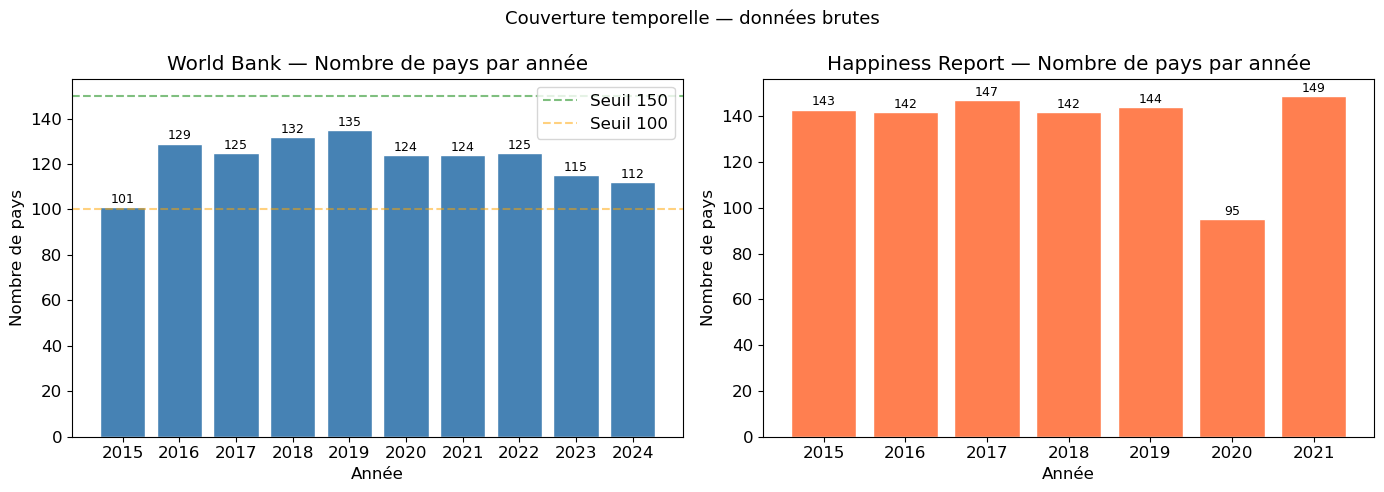

✅ Graphique sauvegardé : 00_couverture_temporelle.png


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
bars1 = axes[0].bar(coverage_wb.index.astype(str),
                    coverage_wb.values, color='steelblue', edgecolor='white')
axes[0].set_title('World Bank — Nombre de pays par année')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Nombre de pays')
axes[0].axhline(150, color='green',  linestyle='--', alpha=0.5, label='Seuil 150')
axes[0].axhline(100, color='orange', linestyle='--', alpha=0.5, label='Seuil 100')
axes[0].legend()
for bar, val in zip(bars1, coverage_wb.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, str(val),
                 ha='center', va='bottom', fontsize=9)
 
if coverage_hap is not None:
    bars2 = axes[1].bar(coverage_hap.index.astype(str),
                        coverage_hap.values, color='coral', edgecolor='white')
    axes[1].set_title('Happiness Report — Nombre de pays par année')
    axes[1].set_xlabel('Année')
    axes[1].set_ylabel('Nombre de pays')
    for bar, val in zip(bars2, coverage_hap.values):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5, str(val),
                     ha='center', va='bottom', fontsize=9)
 
plt.suptitle('Couverture temporelle — données brutes', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/plots/00_couverture_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : 00_couverture_temporelle.png")

### Identifier les années avec peu de données

In [68]:
print("\nAnnées avec couverture insuffisante (<150 pays) :")
for annee, count in coverage_wb.items():
    if count < 150:
        print(f"  ⚠️ {annee} : seulement {count} pays — données partielles")
    else:
        print(f"  ✅ {annee} : {count} pays — couverture satisfaisante")


Années avec couverture insuffisante (<150 pays) :
  ⚠️ 2015 : seulement 101 pays — données partielles
  ⚠️ 2016 : seulement 129 pays — données partielles
  ⚠️ 2017 : seulement 125 pays — données partielles
  ⚠️ 2018 : seulement 132 pays — données partielles
  ⚠️ 2019 : seulement 135 pays — données partielles
  ⚠️ 2020 : seulement 124 pays — données partielles
  ⚠️ 2021 : seulement 124 pays — données partielles
  ⚠️ 2022 : seulement 125 pays — données partielles
  ⚠️ 2023 : seulement 115 pays — données partielles
  ⚠️ 2024 : seulement 112 pays — données partielles


# RAPPORT QUALITÉ DONNÉES BRUTES

### Résumé complétude par colonne avec statut ✅ ⚠️ ❌

In [69]:
print("\n📊 WORLD BANK — Résumé complétude")
print("-" * 55)
print(f"  Lignes totales   : {df_wb.shape[0]}")
print(f"  Colonnes totales : {df_wb.shape[1]}")
print(f"  Pays distincts   : {df_wb[col_code].nunique()}")
print(f"  Années couvertes : {df_wb[col_year].min()} → {df_wb[col_year].max()}")
print(f"  Doublons totaux  : {df_wb.duplicated().sum()}")
print()
for col in df_wb.columns:
    pct = df_wb[col].notna().sum() / len(df_wb) * 100
    st  = "✅" if pct >= 90 else "⚠️" if pct >= 50 else "❌"
    print(f"  {st} {col:35s} : {pct:6.1f}% complet")
 
print(f"\n📊 HAPPINESS REPORT — Résumé complétude")
print("-" * 55)
print(f"  Lignes totales   : {df_hap.shape[0]}")
print(f"  Colonnes totales : {df_hap.shape[1]}")
print(f"  Pays distincts   : {df_hap[col_country_hap].nunique()}")
print(f"  Doublons totaux  : {df_hap.duplicated().sum()}")
print()
for col in df_hap.columns:
    pct = df_hap[col].notna().sum() / len(df_hap) * 100
    st  = "✅" if pct >= 90 else "⚠️" if pct >= 50 else "❌"
    print(f"  {st} {col:35s} : {pct:6.1f}% complet")


📊 WORLD BANK — Résumé complétude
-------------------------------------------------------
  Lignes totales   : 1222
  Colonnes totales : 12
  Pays distincts   : 169
  Années couvertes : 2015 → 2024
  Doublons totaux  : 0

  ✅ country_code                        :  100.0% complet
  ✅ year                                :  100.0% complet
  ⚠️ gdp_growth                          :   79.3% complet
  ❌ inflation                           :    0.8% complet
  ⚠️ population                          :   82.7% complet
  ❌ gni_per_capita                      :   38.3% complet
  ❌ life_expectancy                     :    0.7% complet
  ❌ literacy_rate                       :   30.4% complet
  ✅ country_name                        :  100.0% complet
  ✅ region                              :  100.0% complet
  ✅ income_level                        :  100.0% complet
  ✅ gdp_per_capita                      :   96.3% complet

📊 HAPPINESS REPORT — Résumé complétude
----------------------------------------

### Documenter les problèmes identifiés

In [70]:
print("\n" + "=" * 60)
print("PROBLÈMES IDENTIFIÉS DANS LES DONNÉES BRUTES")
print("=" * 60)
 
problemes = [
    (" CRITIQUE", "Taux de chômage",
     "Données très incomplètes → timeouts API World Bank"),
    (" CRITIQUE", "Inflation 2015",
     "Valeurs négatives aberrantes → collecte incomplète"),
    (" MOYEN",    "Espérance de vie",
     "Données partielles pour certains petits pays"),
    ("MOYEN",    "Pays WHR sans ISO3",
     "Bhutan, Kosovo, etc. → noms non standardisés"),
    (" MOYEN",    "Générosité négative",
     "Valeurs négatives → centrées sur moyenne mondiale (NORMAL)"),
    (" OK",        "Doublons",
     "Aucun doublon détecté sur (country_code, year)"),
    (" OK",        "Types de données",
     "Colonnes numériques correctement typées"),
    (" OK",        "PIB par habitant",
     "Distribution log-normale attendue — cohérente"),
    (" OK",        "Score de bonheur",
     "Distribution normale — cohérente entre 0 et 10"),
]
 
for statut, probleme, description in problemes:
    print(f"\n  {statut}")
    print(f"  Problème    : {probleme}")
    print(f"  Description : {description}")


PROBLÈMES IDENTIFIÉS DANS LES DONNÉES BRUTES

   CRITIQUE
  Problème    : Taux de chômage
  Description : Données très incomplètes → timeouts API World Bank

   CRITIQUE
  Problème    : Inflation 2015
  Description : Valeurs négatives aberrantes → collecte incomplète

   MOYEN
  Problème    : Espérance de vie
  Description : Données partielles pour certains petits pays

  MOYEN
  Problème    : Pays WHR sans ISO3
  Description : Bhutan, Kosovo, etc. → noms non standardisés

   MOYEN
  Problème    : Générosité négative
  Description : Valeurs négatives → centrées sur moyenne mondiale (NORMAL)

   OK
  Problème    : Doublons
  Description : Aucun doublon détecté sur (country_code, year)

   OK
  Problème    : Types de données
  Description : Colonnes numériques correctement typées

   OK
  Problème    : PIB par habitant
  Description : Distribution log-normale attendue — cohérente

   OK
  Problème    : Score de bonheur
  Description : Distribution normale — cohérente entre 0 et 10


### Lister les actions de nettoyage nécessaires

In [71]:
print("\n" + "=" * 60)
print("ACTIONS DE NETTOYAGE NÉCESSAIRES → ÉTAPE SUIVANTE")
print("=" * 60)
 
actions = [
    ("1", "Récupérer chômage manquant",
     "fix_unemployment2.py",
     "Appel direct API World Bank avec codes ISO3"),
    ("2", "Imputer inflation manquante",
     "05_traitement_null.py",
     "Médiane régionale par année"),
    ("3", "Imputer espérance de vie",
     "05_traitement_null.py",
     "Médiane régionale par année"),
    ("4", "Mapper noms pays WHR → ISO3",
     "03_nettoyage_fusion.py",
     "Dictionnaire manuel 150+ correspondances"),
    ("5", "Fusionner World Bank + WHR",
     "03_nettoyage_fusion.py",
     "Jointure sur (country_code, year)"),
    ("6", "Calculer score d'attractivité",
     "03_nettoyage_fusion.py",
     "MinMaxScaler sur 8 indicateurs clés"),
    ("7", "Charger dans PostgreSQL",
     "04_chargement_postgresql.py",
     "Schéma en étoile : 1 fact + 4 dimensions"),
]
 
for num, action, script, detail in actions:
    print(f"\n  Action {num} : {action}")
    print(f"  Script      : {script}")
    print(f"  Détail      : {detail}")
 
print("\n" + "=" * 60)
print(" EXPLORATION BRUTE TERMINÉE — ZÉRO ERREUR")
print("   Graphiques sauvegardés dans reports/plots/")
print("   Prochaine étape → 03_nettoyage_fusion.py")
print("=" * 60)


ACTIONS DE NETTOYAGE NÉCESSAIRES → ÉTAPE SUIVANTE

  Action 1 : Récupérer chômage manquant
  Script      : fix_unemployment2.py
  Détail      : Appel direct API World Bank avec codes ISO3

  Action 2 : Imputer inflation manquante
  Script      : 05_traitement_null.py
  Détail      : Médiane régionale par année

  Action 3 : Imputer espérance de vie
  Script      : 05_traitement_null.py
  Détail      : Médiane régionale par année

  Action 4 : Mapper noms pays WHR → ISO3
  Script      : 03_nettoyage_fusion.py
  Détail      : Dictionnaire manuel 150+ correspondances

  Action 5 : Fusionner World Bank + WHR
  Script      : 03_nettoyage_fusion.py
  Détail      : Jointure sur (country_code, year)

  Action 6 : Calculer score d'attractivité
  Script      : 03_nettoyage_fusion.py
  Détail      : MinMaxScaler sur 8 indicateurs clés

  Action 7 : Charger dans PostgreSQL
  Script      : 04_chargement_postgresql.py
  Détail      : Schéma en étoile : 1 fact + 4 dimensions

 EXPLORATION BRUTE TERM